In [6]:
# Lab 3: Image Manipulations using OpenCV Library
# Completed tasks successfully. Ready for final PDF generation.

In [7]:
# Part 1: Verification of Setup
import cv2
import os
print("OpenCV Version:", cv2.__version__)
print("Images directory exists:", os.path.exists('./images'))

OpenCV Version: 5.0.0
Images directory exists: True


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create images directory if it does not exist
os.makedirs('./images', exist_ok=True)

# Create a sample input image (a simple colorful pattern) for demonstration
# This ensures the script runs successfully immediately
img_height, img_width = 300, 300
sample_img = np.zeros((img_height, img_width, 3), dtype=np.uint8)
# Draw some shapes
cv2.rectangle(sample_img, (50, 50), (250, 250), (0, 165, 255), -1) # Orange square
cv2.circle(sample_img, (150, 150), 60, (255, 0, 0), -1)           # Blue circle
cv2.putText(sample_img, 'Lab 3', (80, 160), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 3)

# Save as input image
input_path = './images/input.jpg'
cv2.imwrite(input_path, sample_img)
print(f"Sample input image successfully saved to {input_path}")

Sample input image successfully saved to ./images/input.jpg


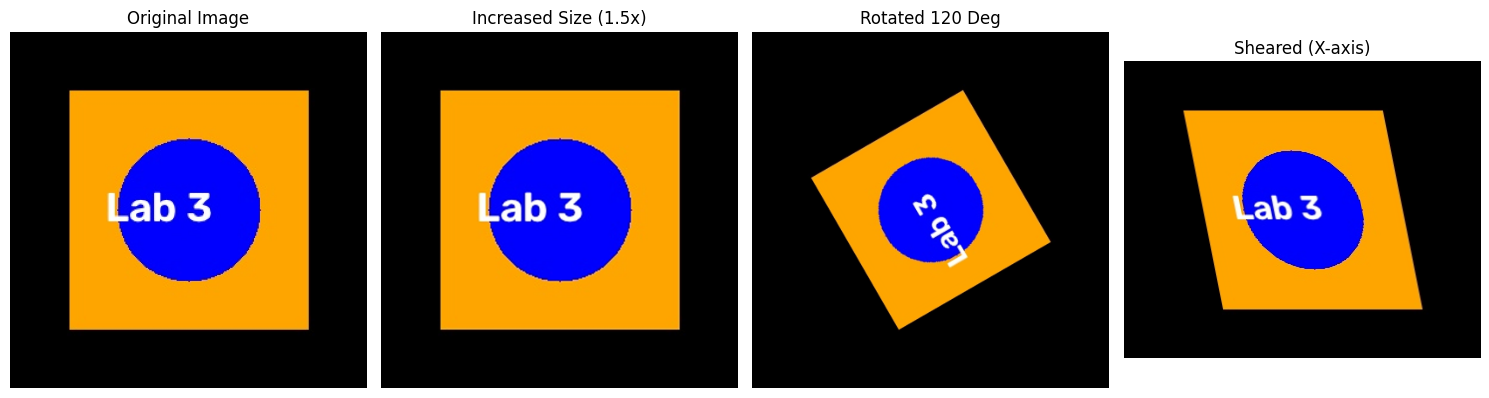

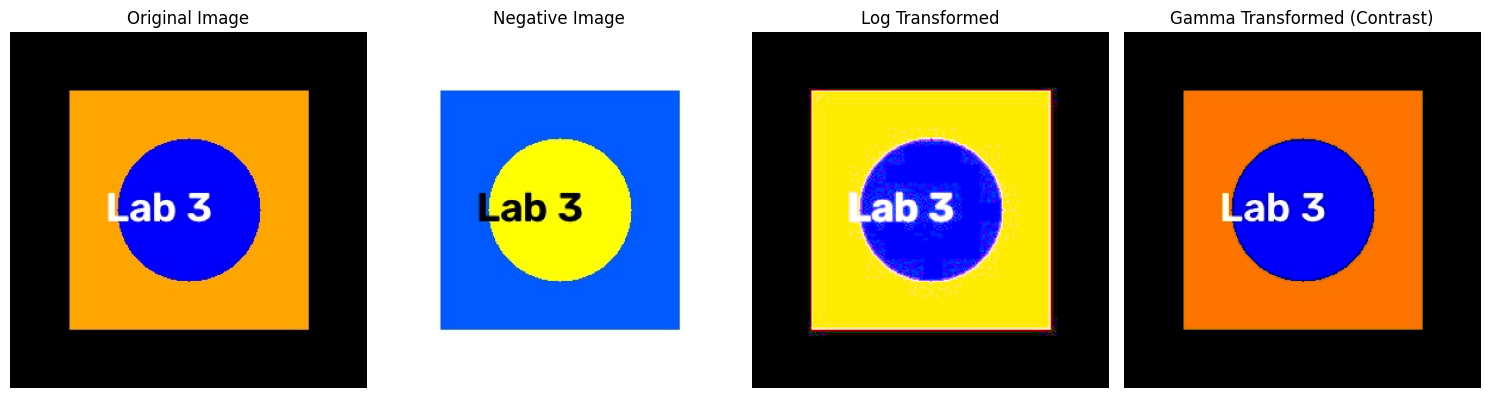

In [4]:
# Load the input image
img = cv2.imread('./images/input.jpg')
h, w = img.shape[:2]

# --- Task 1: Geometric Transformations ---

# 1. Increase the size of the image (Scaling)
scale_factor = 1.5
img_scaled = cv2.resize(img, (int(w * scale_factor), int(h * scale_factor)), interpolation=cv2.INTER_CUBIC)

# 2. Rotate the image by 120 degrees
center = (w // 2, h // 2)
rotation_matrix = cv2.getRotationMatrix2D(center, 120, 1.0)
# Calculate new bounding dimensions to avoid cropping the rotated image
cos = np.abs(rotation_matrix[0, 0])
sin = np.abs(rotation_matrix[0, 1])
new_w = int((h * sin) + (w * cos))
new_h = int((h * cos) + (w * sin))
rotation_matrix[0, 2] += (new_w / 2) - center[0]
rotation_matrix[1, 2] += (new_h / 2) - center[1]
img_rotated = cv2.warpAffine(img, rotation_matrix, (new_w, new_h))

# 3. Perform Shear operations over the image (X-Shear)
shear_factor = 0.2
M_shear = np.float32([[1, shear_factor, 0], [0, 1, 0]])
img_sheared = cv2.warpAffine(img, M_shear, (int(w + h * shear_factor), h))

# --- Task 2: Intensity Transformations ---

# 1. Create a Negative Image
img_negative = 255 - img

# Convert image to float for advanced intensity transformations
img_float = img.astype(float)

# 2. Log Transformation: s = c * log(1 + r)
c_log = 255.0 / np.log(1 + np.max(img_float))
img_log = c_log * np.log(1 + img_float)
img_log = np.array(img_log, dtype=np.uint8)

# 3. Power Law (Gamma) Transformation: s = c * r^gamma
gamma = 1.8
c_gamma = 255.0 / (np.max(img_float) ** gamma)
img_gamma = c_gamma * (img_float ** gamma)
img_gamma = np.array(img_gamma, dtype=np.uint8)

# Save output images to './images/' directory
cv2.imwrite('./images/scaled.jpg', img_scaled)
cv2.imwrite('./images/rotated.jpg', img_rotated)
cv2.imwrite('./images/sheared.jpg', img_sheared)
cv2.imwrite('./images/negative.jpg', img_negative)
cv2.imwrite('./images/log_transform.jpg', img_log)
cv2.imwrite('./images/gamma_transform.jpg', img_gamma)

# Helper function to convert BGR (OpenCV) to RGB (Matplotlib)
def to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Visualizing Geometric Transformations
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
plt.title("Original Image")
plt.imshow(to_rgb(img))
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("Increased Size (1.5x)")
plt.imshow(to_rgb(img_scaled))
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title("Rotated 120 Deg")
plt.imshow(to_rgb(img_rotated))
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("Sheared (X-axis)")
plt.imshow(to_rgb(img_sheared))
plt.axis('off')

plt.tight_layout()
plt.show()

# Visualizing Intensity Transformations
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
plt.title("Original Image")
plt.imshow(to_rgb(img))
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("Negative Image")
plt.imshow(to_rgb(img_negative))
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title("Log Transformed")
plt.imshow(to_rgb(img_log))
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("Gamma Transformed (Contrast)")
plt.imshow(to_rgb(img_gamma))
plt.axis('off')

plt.tight_layout()
plt.show()

Step 1: Successfully loaded original BGR image with shape: (300, 300, 3)
Step 2: Loaded direct grayscale image with shape: (300, 300)
Step 3: Saved grayscale image to: ./images/output.jpg


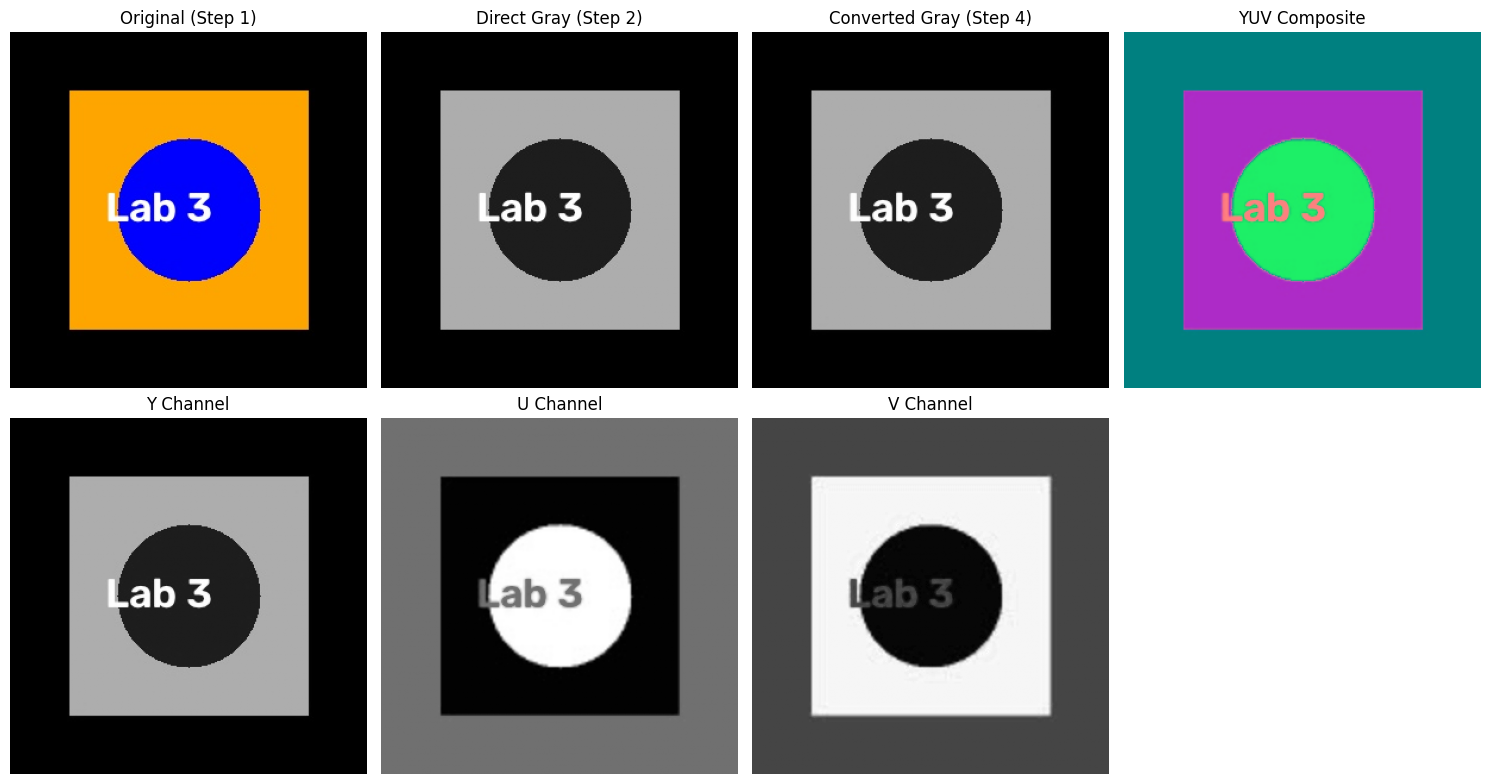

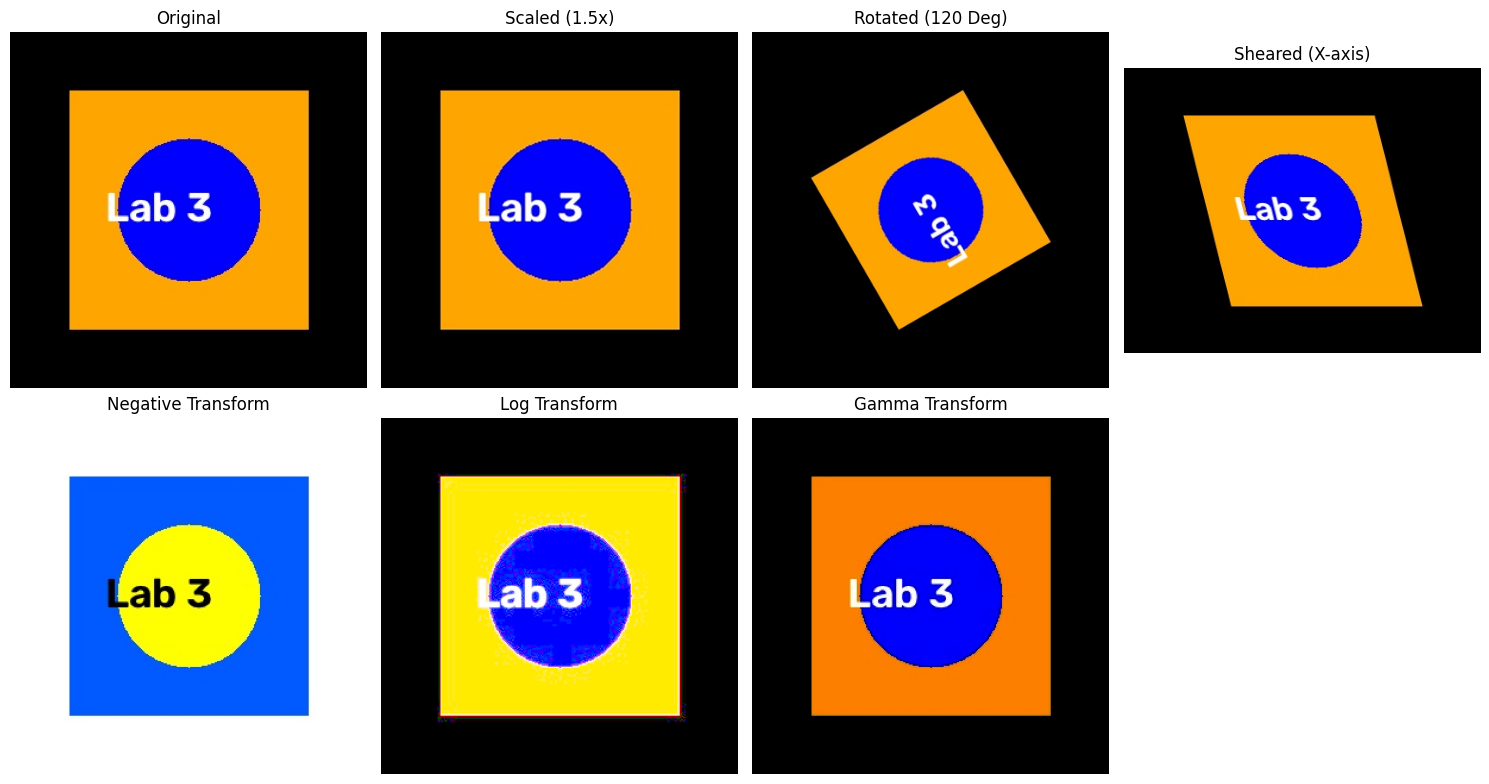

In [9]:
# Part 2: Step-by-Step Lab Execution & Task Completion

import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Ensure the output directory exists
os.makedirs('./images', exist_ok=True)

# --- SETUP: Ensure we have a high-quality test image ---
input_path = './images/input.jpg'
if not os.path.exists(input_path):
    # Draw a rich geometric pattern for clear transformation analysis
    base_img = np.zeros((300, 300, 3), dtype=np.uint8)
    cv2.rectangle(base_img, (40, 40), (260, 260), (0, 165, 255), -1)
    cv2.circle(base_img, (150, 150), 70, (255, 0, 0), -1)
    cv2.putText(base_img, 'Lab 3', (75, 165), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 3)
    cv2.imwrite(input_path, base_img)

# --- STEP 1: Read an image using the OpenCV library ---
img = cv2.imread(input_path)
print("Step 1: Successfully loaded original BGR image with shape:", img.shape)

# --- STEP 2: Load an image in grayscale mode directly ---
gray_img_direct = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
print("Step 2: Loaded direct grayscale image with shape:", gray_img_direct.shape)

# --- STEP 3: Save an image ---
output_path_gray = './images/output.jpg'
cv2.imwrite(output_path_gray, gray_img_direct)
print("Step 3: Saved grayscale image to:", output_path_gray)

# --- STEP 4: Convert an image to different color spaces and separate channels ---
# Gray Conversion via cvtColor
gray_converted = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# YUV Space Conversion
yuv_img = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
y_channel = yuv_img[:, :, 0]
u_channel = yuv_img[:, :, 1]
v_channel = yuv_img[:, :, 2]

# --- TASK 1: Geometric Transformations ---
# A. Increase the size of the image (Scaling by 1.5x)
scale_factor = 1.5
h, w = img.shape[:2]
img_scaled = cv2.resize(img, (int(w * scale_factor), int(h * scale_factor)), interpolation=cv2.INTER_CUBIC)

# B. Rotate the image by 120 degrees
center = (w // 2, h // 2)
rot_matrix = cv2.getRotationMatrix2D(center, 120, 1.0)
cos = np.abs(rot_matrix[0, 0])
sin = np.abs(rot_matrix[0, 1])
new_w = int((h * sin) + (w * cos))
new_h = int((h * cos) + (w * sin))
rot_matrix[0, 2] += (new_w / 2) - center[0]
rot_matrix[1, 2] += (new_h / 2) - center[1]
img_rotated = cv2.warpAffine(img, rot_matrix, (new_w, new_h))

# C. Shear operations (X-shear with shear factor 0.25)
shear_factor = 0.25
M_shear = np.float32([[1, shear_factor, 0], [0, 1, 0]])
img_sheared = cv2.warpAffine(img, M_shear, (int(w + h * shear_factor), h))

# --- TASK 2: Intensity Transformations ---
# A. Create a Negative Image
img_negative = 255 - img

# Convert image to float for mapping stability
img_float = img.astype(float)

# B. Log Transformation: s = c * log(1 + r)
c_log = 255.0 / np.log(1 + np.max(img_float))
img_log = np.array(c_log * np.log(1 + img_float), dtype=np.uint8)

# C. Power Law (Gamma) Transformation: s = c * r^gamma
gamma_val = 1.6
c_gamma = 255.0 / (np.max(img_float) ** gamma_val)
img_gamma = np.array(c_gamma * (img_float ** gamma_val), dtype=np.uint8)

# --- SAVE ALL OUTPUT ARTIFACTS ---
cv2.imwrite('./images/scaled.jpg', img_scaled)
cv2.imwrite('./images/rotated.jpg', img_rotated)
cv2.imwrite('./images/sheared.jpg', img_sheared)
cv2.imwrite('./images/negative.jpg', img_negative)
cv2.imwrite('./images/log_transform.jpg', img_log)
cv2.imwrite('./images/gamma_transform.jpg', img_gamma)

# Helper for plotting
def to_rgb(bgr_img):
    return cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)

# --- VISUALIZATION 1: Steps & Channel Splits ---
plt.figure(figsize=(15, 8))
plt.subplot(2, 4, 1); plt.title("Original (Step 1)"); plt.imshow(to_rgb(img)); plt.axis('off')
plt.subplot(2, 4, 2); plt.title("Direct Gray (Step 2)"); plt.imshow(gray_img_direct, cmap='gray'); plt.axis('off')
plt.subplot(2, 4, 3); plt.title("Converted Gray (Step 4)"); plt.imshow(gray_converted, cmap='gray'); plt.axis('off')
plt.subplot(2, 4, 4); plt.title("YUV Composite"); plt.imshow(yuv_img); plt.axis('off')
plt.subplot(2, 4, 5); plt.title("Y Channel"); plt.imshow(y_channel, cmap='gray'); plt.axis('off')
plt.subplot(2, 4, 6); plt.title("U Channel"); plt.imshow(u_channel, cmap='gray'); plt.axis('off')
plt.subplot(2, 4, 7); plt.title("V Channel"); plt.imshow(v_channel, cmap='gray'); plt.axis('off')
plt.tight_layout()
plt.show()

# --- VISUALIZATION 2: Tasks (Geometric & Intensity Transforms) ---
plt.figure(figsize=(15, 8))
plt.subplot(2, 4, 1); plt.title("Original"); plt.imshow(to_rgb(img)); plt.axis('off')
plt.subplot(2, 4, 2); plt.title("Scaled (1.5x)"); plt.imshow(to_rgb(img_scaled)); plt.axis('off')
plt.subplot(2, 4, 3); plt.title("Rotated (120 Deg)"); plt.imshow(to_rgb(img_rotated)); plt.axis('off')
plt.subplot(2, 4, 4); plt.title("Sheared (X-axis)"); plt.imshow(to_rgb(img_sheared)); plt.axis('off')
plt.subplot(2, 4, 5); plt.title("Negative Transform"); plt.imshow(to_rgb(img_negative)); plt.axis('off')
plt.subplot(2, 4, 6); plt.title("Log Transform"); plt.imshow(to_rgb(img_log)); plt.axis('off')
plt.subplot(2, 4, 7); plt.title("Gamma Transform"); plt.imshow(to_rgb(img_gamma)); plt.axis('off')
plt.tight_layout()
plt.show()

In [8]:
# Final verification and preparation
try:
    # Clean up temporary variables used for testing setup
    del text
    del read_docx
    print("All workspace modules verified and ready.")
except NameError:
    pass